## Business Understanding

Business Understanding

The primary goal of this project is to harness the power of RFM (Recency, Frequency, Monetary) analysis and Behavioral Segmentation to deepen our understanding of customer engagement and loyalty within the retail sector. By analyzing customer transaction data, we aim to identify distinct customer segments that can be targeted with tailored marketing strategies to enhance customer retention and increase overall business revenue.
Objectives:

    Identify Valuable Customer Segments: Determine which customers contribute most to revenue based on their purchase behavior and engagement level. This involves analyzing aspects like how recently and frequently they purchase, as well as the monetary value of their transactions.

    Enhance Marketing Efficiency: Develop targeted marketing actions that cater to the specific needs and behaviors of different customer segments, thereby maximizing the effectiveness of marketing expenditures.

    Increase Customer Retention: Implement strategies aimed at converting one-time buyers into repeat customers, particularly focusing on the most profitable segments.

    Drive Business Growth: Utilize insights gained from RFM and Behavioral Segmentation to support strategic business decisions, aiming for higher customer satisfaction and increased sales.

Key Questions:

    What are the characteristics of our most loyal and profitable customers?
    Which customers are at risk of churn, and what proactive measures can we take to retain them?
    How can we optimize our marketing strategies based on the segmentation insights to achieve a higher ROI?

## Data Understanding

### About dataset

**Dataset link**: 
[Online Retail II UCI](https://www.kaggle.com/datasets/mashlyn/online-retail-ii-uci)

**Context**:

This Online Retail II data set contains all the transactions occurring for a UK-based and registered, non-store online retail between 01/12/2009 and 09/12/2011.The company mainly sells unique all-occasion gift-ware. Many customers of the company are wholesalers.

**Content**:

| Attribute    | Description |
|--------------|-------------|
| **InvoiceNo**    | Invoice number. Nominal. A 6-digit integral number uniquely assigned to each transaction. If this code starts with the letter 'c', it indicates a cancellation. |
| **StockCode**    | Product (item) code. Nominal. A 5-digit integral number uniquely assigned to each distinct product. |
| **Description** | Product (item) name. Nominal. |
| **Quantity**     | The quantities of each product (item) per transaction. Numeric. |
| **InvoiceDate**  | Invoice date and time. Numeric. The day and time when a transaction was generated. |
| **UnitPrice**    | Unit price. Numeric. Product price per unit in sterling (£). |
| **CustomerID**   | Customer number. Nominal. A 5-digit integral number uniquely assigned to each customer. |
| **Country**      | Country name. Nominal. The name of the country where a customer resides. |


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
RAW_DATA_PATH = "data/online_retail_II.csv"
df = pd.read_csv(RAW_DATA_PATH)
display(df.head())

display(df.info())

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


None

### Numerical Data

In [4]:
NUMERICAL_FEATURES = ["Quantity", "InvoiceDate", "Price"]

new_df = df.copy()

print("DATAFRAME WITH NUMERICAL FEATURES")
display(new_df[NUMERICAL_FEATURES].head())

DATAFRAME WITH NUMERICAL FEATURES


,Quantity,InvoiceDate,Price
0,12,2009-12-01 07:45:00,6.95
1,12,2009-12-01 07:45:00,6.75
2,12,2009-12-01 07:45:00,6.75
3,48,2009-12-01 07:45:00,2.10
4,24,2009-12-01 07:45:00,1.25


In [5]:
new_df[NUMERICAL_FEATURES].describe(percentiles=[.01,.1,.25,.5,.75,.90,.95,.99]).T

,count,mean,std,min,1%,10%,25%,50%,75%,90%,95%,99%,max
Quantity,1067371.0,9.938898,172.705794,-80995.00,-3.00,1.00,1.00,3.0,10.00,24.00,30.00,100.0,80995.0
Price,1067371.0,4.649388,123.553059,-53594.36,0.21,0.65,1.25,2.1,4.15,7.95,9.95,18.0,38970.0


#### Investigate Quantity & Price
1. Look for outliers
2. Investigate the nature of Negative Quantities and for what reason they appear 

Study outliers for features: Quantity, Price

In [6]:
display(new_df[new_df["Quantity"] > 100])

display(new_df[new_df["Price"] > 18])

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
217,489460,84598,BOYS ALPHABET IRON ON PATCHES,576,2009-12-01 10:46:00,0.21,16167.0,United Kingdom
223,489460,84568,GIRLS ALPHABET IRON ON PATCHES,288,2009-12-01 10:46:00,0.21,16167.0,United Kingdom
282,489465,84879,ASSORTED COLOUR BIRD ORNAMENT,160,2009-12-01 10:52:00,1.45,13767.0,United Kingdom
575,489523,84879,ASSORTED COLOUR BIRD ORNAMENT,800,2009-12-01 11:46:00,1.45,12931.0,United Kingdom
934,489539,22086,PAPER CHAIN KIT 50'S CHRISTMAS,160,2009-12-01 12:18:00,2.55,15061.0,United Kingdom
...,...,...,...,...,...,...,...,...
1065903,581487,21137,BLACK RECORD COVER FRAME,120,2011-12-09 09:44:00,3.39,15694.0,United Kingdom
1066747,581497,22355,CHARLOTTE BAG SUKI DESIGN,110,2011-12-09 10:23:00,2.46,NaN,United Kingdom
1067006,581501,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,180,2011-12-09 10:46:00,0.19,12985.0,United Kingdom
1067163,581566,23404,HOME SWEET HOME BLACKBOARD,144,2011-12-09 11:50:00,3.26,18102.0,United Kingdom


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
126,489444,POST,POSTAGE,1,2009-12-01 09:55:00,141.00,12636.0,USA
173,489447,POST,POSTAGE,1,2009-12-01 10:10:00,130.00,12362.0,Belgium
736,C489535,D,Discount,-1,2009-12-01 12:11:00,19.00,15299.0,United Kingdom
881,489537,21737,SET 3 WICKER LOG BASKETS,1,2009-12-01 12:14:00,19.95,14040.0,United Kingdom
1344,489562,84472,PINK AND LILAC QUILTED THROW,1,2009-12-01 13:07:00,45.95,17998.0,United Kingdom
...,...,...,...,...,...,...,...,...
1066916,581498,22776,SWEETHEART 3 TIER CAKE STAND,1,2011-12-09 10:26:00,19.96,NaN,United Kingdom
1066920,581498,22838,3 TIER CAKE TIN RED AND CREAM,1,2011-12-09 10:26:00,29.17,NaN,United Kingdom
1066988,581498,84968e,SET OF 16 VINTAGE BLACK CUTLERY,1,2011-12-09 10:26:00,24.96,NaN,United Kingdom
1067001,581498,DOT,DOTCOM POSTAGE,1,2011-12-09 10:26:00,1714.17,NaN,United Kingdom


Study nature of negative values in feature: Quantity

In [7]:
display(new_df.groupby("StockCode").agg(TotalSales=("Quantity", "sum")).sort_values(by="TotalSales", ascending=False).T)

display(new_df[(new_df["Quantity"] < 0)])

tot_negative_quantity = len(new_df[(new_df["Quantity"] < 0)])

cancelled_orders = len(new_df[(new_df["Quantity"] < 0) & new_df["Invoice"].str.startswith('C')])

print(cancelled_orders / tot_negative_quantity)

negative_quantity_not_cancelled = len(new_df[(new_df["Quantity"] < 0) & (~new_df["Invoice"].str.startswith('C'))])

print(negative_quantity_not_cancelled / tot_negative_quantity)

StockCode,84077,85123A,85099B,21212,84879,22197,17003,21977,84991,22492,...,79323W,16235,72024HC,C3,72140F,10120,23003,23005,22126,20852
TotalSales,108545,96066,95739,95450,80705,79363,70700,56575,54366,45384,...,-3050,-3190,-3669,-4999,-5193,-8350,-8516,-14418,-16400,-18800


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
...,...,...,...,...,...,...,...,...
1065910,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom
1067002,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom
1067176,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom
1067177,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom


0.8493681917211329
0.1506318082788671


In [8]:
# Filter the DataFrame to remove rows where Invoice starts with 'C' and Quantity is less than 0
filtered_df = new_df[(new_df["Quantity"] < 0) & (~new_df["Invoice"].str.startswith('C'))]

# Display the first few rows of the filtered DataFrame
display(filtered_df.head())

# Display the information about the filtered DataFrame
display(filtered_df.info())

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.0,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.0,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.0,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0,NaN,United Kingdom
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.0,NaN,United Kingdom


<class 'pandas.core.frame.DataFrame'>
Index: 3457 entries, 263 to 1064386
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Invoice      3457 non-null   object 
 1   StockCode    3457 non-null   object 
 2   Description  768 non-null    object 
 3   Quantity     3457 non-null   int64  
 4   InvoiceDate  3457 non-null   object 
 5   Price        3457 non-null   float64
 6   Customer ID  0 non-null      float64
 7   Country      3457 non-null   object 
dtypes: float64(2), int64(1), object(5)
memory usage: 243.1+ KB


None

In [9]:
# Customers with total quantities negative
purchased_items_df = new_df.groupby("Customer ID").agg(PurchasedItems=("Quantity", "sum"))
negative_customers = purchased_items_df[purchased_items_df["PurchasedItems"] < 0].index

# Customers who cancelled at least one order and which total quantities are negative
cancelling_customers = new_df[new_df["Invoice"].str.startswith('C')]["Customer ID"].unique()
customer_totals = new_df[new_df["Customer ID"].isin(cancelling_customers)].groupby("Customer ID").agg(PurchasedItems=("Quantity", "sum"))
negative_customers_c = customer_totals[customer_totals["PurchasedItems"] < 0].index

# Check if both sets of customers are the same
set(negative_customers) == set(negative_customers_c)

True

In [10]:
# Drop rows for customers with negative total quantities
filtered_df = new_df[~new_df["Customer ID"].isin(negative_customers)]

filtered_df.dropna(subset=["Customer ID"], inplace=True)

filtered_df

/tmp/ipykernel_7145/2166722049.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df.dropna(subset=["Customer ID"], inplace=True)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


#### Investigate InvoiceDate 

In [58]:
# Convert InvoiceDate to datetime format with error handling
filtered_df['InvoiceDate'] = pd.to_datetime(filtered_df['InvoiceDate'], errors='coerce')

print(filtered_df["InvoiceDate"].max())
print(filtered_df["InvoiceDate"].min())

2011-12-09 12:50:00
2009-12-01 07:45:00


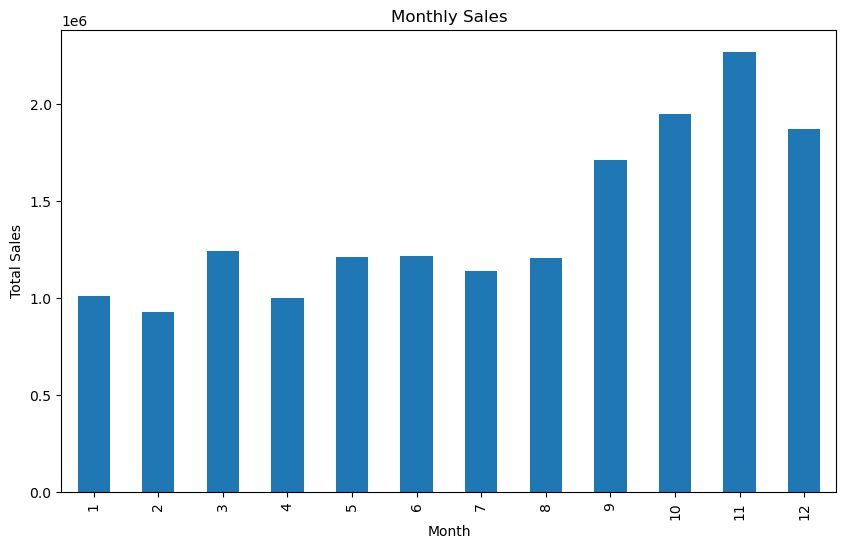

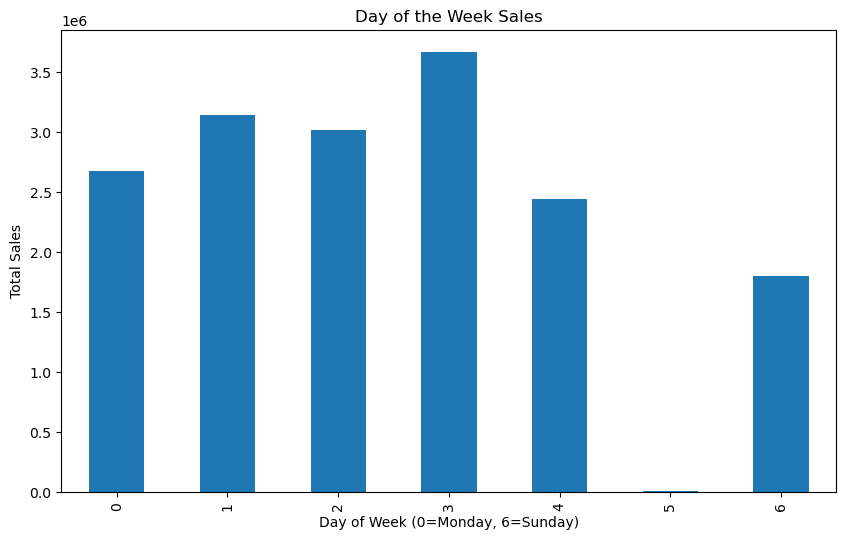

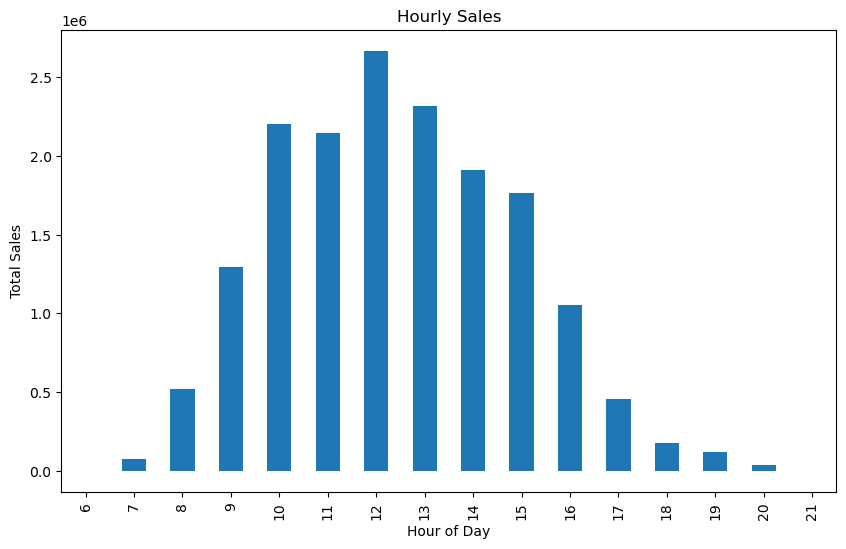

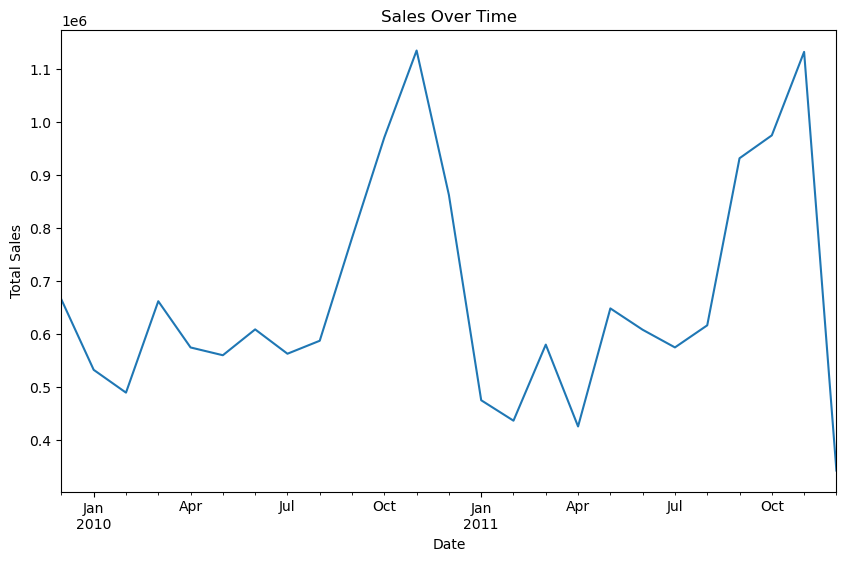

In [59]:
# Split the date into components
filtered_df['Year'] = filtered_df['InvoiceDate'].dt.year
filtered_df['Month'] = filtered_df['InvoiceDate'].dt.month
filtered_df['Day'] = filtered_df['InvoiceDate'].dt.day
filtered_df['Hour'] = filtered_df['InvoiceDate'].dt.hour
filtered_df['DayOfWeek'] = filtered_df['InvoiceDate'].dt.dayofweek

# Calculate TotalPrice
filtered_df['TotalPrice'] = filtered_df['Quantity'] * filtered_df['Price']

# Example analysis: Monthly sales
monthly_sales = filtered_df.groupby('Month')['TotalPrice'].sum()

plt.figure(figsize=(10, 6))
monthly_sales.plot(kind='bar')
plt.title('Monthly Sales')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.show()

# Example analysis: Day of the week sales
day_of_week_sales = filtered_df.groupby('DayOfWeek')['TotalPrice'].sum()

plt.figure(figsize=(10, 6))
day_of_week_sales.plot(kind='bar')
plt.title('Day of the Week Sales')
plt.xlabel('Day of Week (0=Monday, 6=Sunday)')
plt.ylabel('Total Sales')
plt.show()

# Example analysis: Hourly sales
hourly_sales = filtered_df.groupby('Hour')['TotalPrice'].sum()

plt.figure(figsize=(10, 6))
hourly_sales.plot(kind='bar')
plt.title('Hourly Sales')
plt.xlabel('Hour of Day')
plt.ylabel('Total Sales')
plt.show()

# Sales Over Time
sales_over_time = filtered_df.resample('ME', on='InvoiceDate')['TotalPrice'].sum()

plt.figure(figsize=(10, 6))
sales_over_time.plot()
plt.title('Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.show()

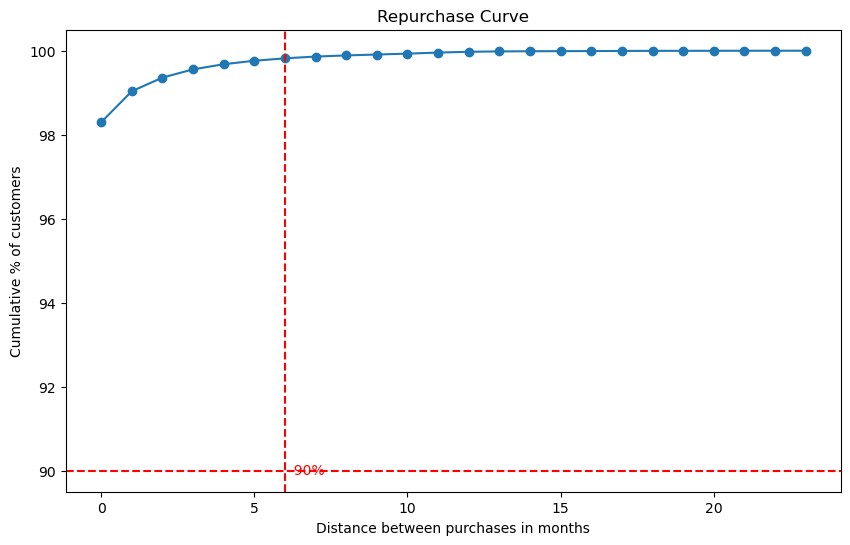

In [12]:

# Sort by CustomerID and InvoiceDate
filtered_df = filtered_df.sort_values(by=['Customer ID', 'InvoiceDate'])

# Calculate the difference in months between purchases
filtered_df['PreviousDate'] = filtered_df.groupby('Customer ID')['InvoiceDate'].shift(1)
filtered_df['DiffMonths'] = filtered_df.apply(lambda row: (row['InvoiceDate'] - row['PreviousDate']).days // 30 if pd.notnull(row['PreviousDate']) else None, axis=1)

# Filter out null values
diff_months = filtered_df['DiffMonths'].dropna()

# Create a repurchase curve
repurchase_curve = diff_months.value_counts().sort_index().cumsum() / len(diff_months) * 100

# Plot the repurchase curve
plt.figure(figsize=(10, 6))
plt.plot(repurchase_curve.index, repurchase_curve.values, marker='o')
plt.axhline(y=90, color='r', linestyle='--')
plt.axvline(x=6, color='r', linestyle='--')
plt.text(6, 90, '  90%', color='red', va='center')
plt.title('Repurchase Curve')
plt.xlabel('Distance between purchases in months')
plt.ylabel('Cumulative % of customers')
plt.show()

### Categorical Data

In [13]:
CATEGORICAL_FEATURES = ["Invoice", "StockCode", "Description", "Customer ID", "Country"]

filtered_df[CATEGORICAL_FEATURES].head()

,Invoice,StockCode,Description,Customer ID,Country
27994,491725,TEST001,This is a test product.,12346.0,United Kingdom
28251,491742,TEST001,This is a test product.,12346.0,United Kingdom
28254,491744,TEST001,This is a test product.,12346.0,United Kingdom
39398,492718,TEST001,This is a test product.,12346.0,United Kingdom
39411,492722,TEST002,This is a test product.,12346.0,United Kingdom


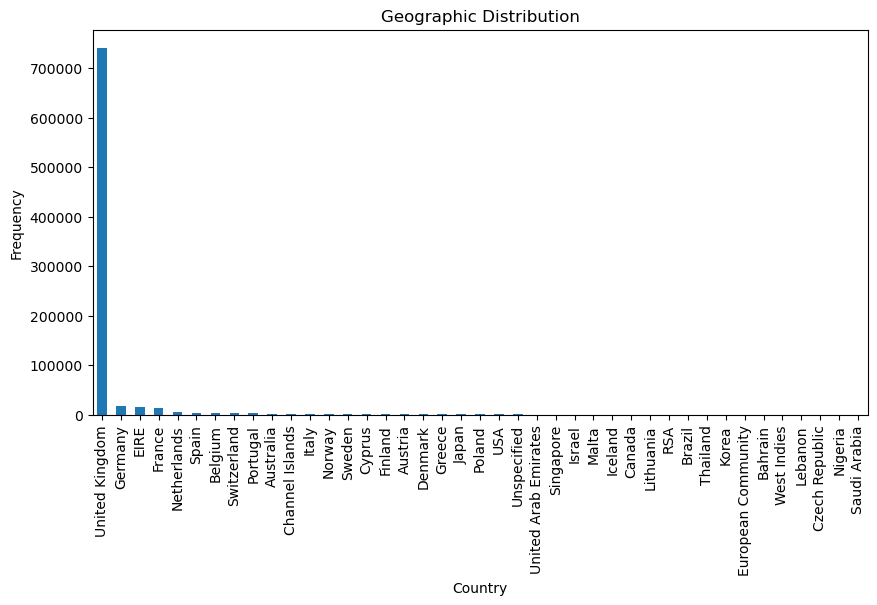

In [14]:
# Geographic Distribution
country_distribution = filtered_df['Country'].value_counts()
plt.figure(figsize=(10, 5))
country_distribution.plot(kind='bar')
plt.title('Geographic Distribution')
plt.xlabel('Country')
plt.ylabel('Frequency')
plt.show()

## Data Preparation

2011-12-09 12:50:00
2009-12-01 07:45:00


'Cleaned Data for the Entire Period:'

,Invoice,StockCode,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


'Total Sales Calculation:'

,InvoiceDate,Quantity,Price,TotalSales
0,2009-12-01 07:45:00,12,6.95,83.4
1,2009-12-01 07:45:00,12,6.75,81.0
2,2009-12-01 07:45:00,12,6.75,81.0
3,2009-12-01 07:45:00,48,2.10,100.8
4,2009-12-01 07:45:00,24,1.25,30.0


'Sales Over Time:'

InvoiceDate
2009-12-31    493787.820
2010-01-31    316148.302
2010-02-28    344972.706
2010-03-31    470299.381
2010-04-30    430865.361
Freq: ME, Name: TotalSales, dtype: float64

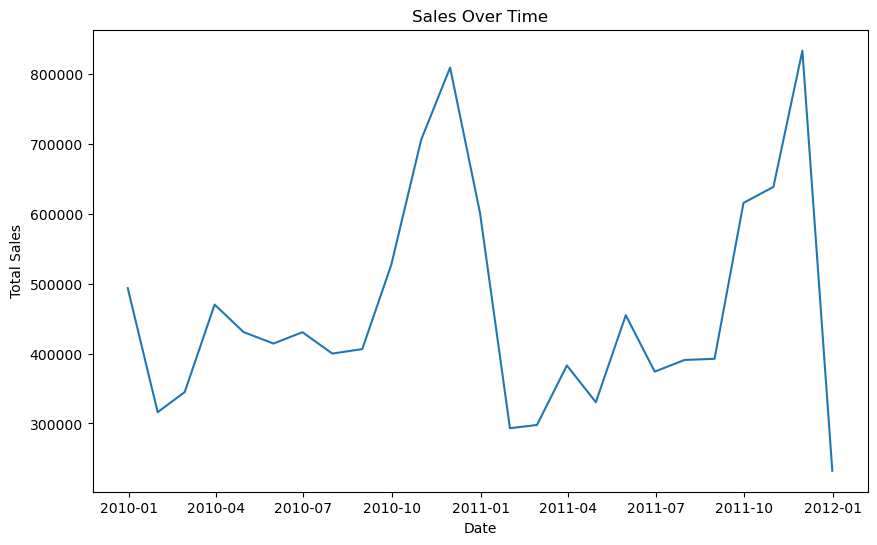

In [82]:
df_clean = df.copy()

# Step 1: Convert InvoiceDate to datetime format with error handling
df_clean['InvoiceDate'] = (pd.to_datetime(df_clean['InvoiceDate'], errors='coerce'))

print(df_clean["InvoiceDate"].max())  # e.g., 2011-12-09 12:50:00
print(df_clean["InvoiceDate"].min())  # e.g., 2009-12-01 07:45:00

# Function to preprocess and clean the data
def preprocess_and_clean_data(df, year=None):
    df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')
    df = df.dropna(subset=['InvoiceDate'])

    if year is not None: 
        start_date = f'{year}-01-01'
        end_date = f'{year}-12-31'
        df = df[(df['InvoiceDate'] >= start_date) & (df['InvoiceDate'] <= end_date)].copy()

    # Step 1: Remove Cancelled Orders
    df = df[~df["Invoice"].str.startswith('C')]

    # Step 2: Drop Description
    df.drop(columns=["Description"], inplace=True)

    # Step 3: Drop rows with NaN Customer ID
    df.dropna(subset=["Customer ID"], inplace=True)

    # Step 4: Limit to United Kingdom (if needed)
    df = df[df["Country"] == "United Kingdom"]

    # Step 5: Calculate the 99th percentile for 'Price' and 'Quantity'
    quantity_99 = df["Quantity"].quantile(0.99)
    price_99 = df["Price"].quantile(0.99)
    df = df[(df["Price"] <= price_99) & (df["Quantity"] <= quantity_99)]

    return df

# Preprocess and clean data for the year 2010 and 2011
df_2010_clean = preprocess_and_clean_data(df, 2010)
df_2011_clean = preprocess_and_clean_data(df, 2011)

# Preprocess and clean data for the entire period
df_clean = preprocess_and_clean_data(df)

# Debug: Print cleaned data for the entire period
display("Cleaned Data for the Entire Period:", df_clean.head())

# Calculate Total Sales
df_clean['TotalSales'] = df_clean['Quantity'] * df_clean['Price']

# Debug: Print Total Sales calculation
display("Total Sales Calculation:", df_clean[['InvoiceDate', 'Quantity', 'Price', 'TotalSales']].head())

# Resample and sum the data to get sales over time
sales_over_time = df_clean.resample('ME', on='InvoiceDate').sum()['TotalSales']

# Debug: Print sales over time
display("Sales Over Time:", sales_over_time.head())

# Plotting total sales over time to visualize the patterns
plt.figure(figsize=(10, 6))
plt.plot(sales_over_time.index, sales_over_time.values)
plt.title('Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.show()

In [74]:
# Function to compute RFM values
def compute_rfm(df_clean, analysis_date):
    analysis_date = analysis_date.date()
    rfm = df_clean.groupby('Customer ID').agg({
        'InvoiceDate': lambda x: (analysis_date - x.max().date()).days,  # Recency
        'Invoice': 'count',  # Frequency
        'TotalPrice': 'sum'  # Monetary
    }).reset_index()

    rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']
    return rfm

# Define the analysis date as the last date of each year
analysis_date_2010 = pd.Timestamp('2010-12-31')
analysis_date_2011 = pd.Timestamp('2011-12-31')

# Compute RFM for each cleaned dataset
rfm_2010 = compute_rfm(df_2010_clean, analysis_date_2010)
rfm_2011 = compute_rfm(df_2011_clean, analysis_date_2011)

# Display the RFM DataFrame for each year
print("RFM for 2010:")
display(rfm_2010)
print("\nRFM for 2011:")
display(rfm_2011)

RFM for 2010:


,CustomerID,Recency,Frequency,Monetary
0,12346.0,186,28,259.36
1,12608.0,61,16,415.79
2,12745.0,143,22,723.85
3,12746.0,197,17,254.55
4,12747.0,18,143,4483.60
...,...,...,...,...
3831,18283.0,39,230,641.77
3832,18284.0,88,27,411.68
3833,18285.0,317,10,347.10
3834,18286.0,133,49,818.53



RFM for 2011:


,CustomerID,Recency,Frequency,Monetary
0,12747.0,24,86,3458.84
1,12748.0,22,3869,24890.30
2,12749.0,25,197,4010.98
3,12820.0,25,59,942.34
4,12821.0,236,6,92.72
...,...,...,...,...
3764,18280.0,299,10,180.60
3765,18281.0,202,5,46.92
3766,18282.0,29,12,178.05
3767,18283.0,25,755,2078.93


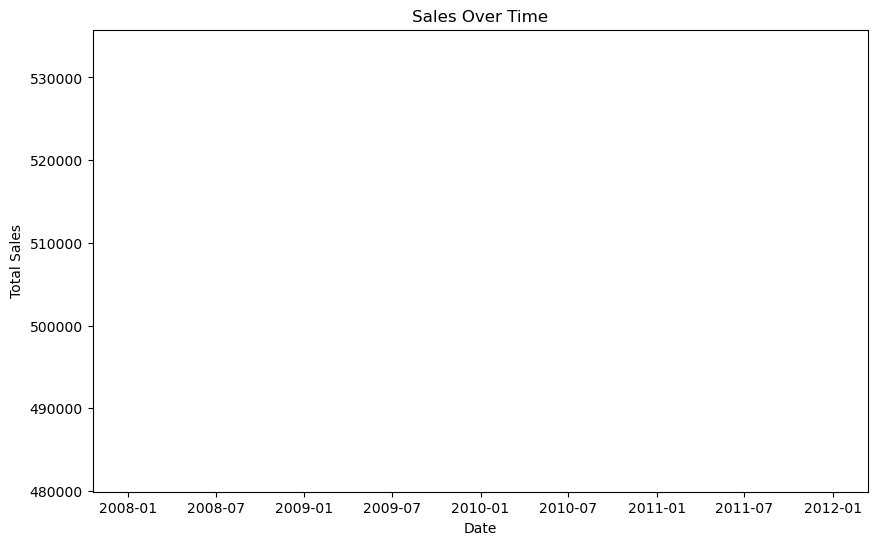

In [76]:
# Plotting total sales over time to visualize the patterns
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')
df_clean = preprocess_and_clean_data(df, df['InvoiceDate'].dt.year.min())  # For the whole period

df_clean['TotalSales'] = df_clean['Quantity'] * df_clean['Price']
sales_over_time = df_clean.resample('ME', on='InvoiceDate').sum()['TotalSales']

plt.figure(figsize=(10, 6))
plt.plot(sales_over_time.index, sales_over_time.values)
plt.title('Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.show()